# Content Analysis and Results — Bluesky

**Project:** *The Devil Wears Prada 2* — Social Media Analysis
**Platform:** Bluesky

This notebook is the final analytical step of the project. It loads the data assembled in the previous notebooks and produces a content-level characterisation of the conversation: descriptive statistics, text preprocessing, sentiment and emotion analysis, named-entity recognition, and a cross-analysis that joins these signals with the community structure identified in `02_network_and_communities.ipynb`.

All figures are saved in `data/figures/`, all derived datasets in `data/processed/`.

**Two scoping decisions** are stated up front:

1. **Sentiment, emotion and NER are restricted to English-tagged texts.** AFINN, VADER, NRCLex and the SpaCy `en_core_web_sm` pipeline are English-only; applying them to Portuguese, Spanish or French posts produces meaningless scores that would contaminate aggregate statistics.
2. **Community-based comparisons concern only the giant component.** The reply graph is highly fragmented and Louvain partitions are defined only for the 88 nodes of the giant component. Texts authored outside the giant component do not carry a community label and are excluded from community-level summaries — but are kept in every other analysis.


## 1. Setup

This section prepares the environment for the content analysis notebook.

- First, the required Python libraries are imported for data manipulation, visualization, text preprocessing, sentiment analysis, emotion analysis and Named Entity Recognition. The notebook uses `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualizations, NLTK for English stopword removal and WordNet lemmatization, VADER and AFINN for sentiment analysis, NRCLex for emotion detection, and spaCy for Named Entity Recognition.

- The setup also downloads the required NLTK resources if they are not already available locally. Since SSL certificate issues can occur on macOS when downloading NLTK resources, the SSL context is temporarily adjusted to avoid download failures.

- The English spaCy model `en_core_web_sm` is then loaded. If the model is not already installed, it is downloaded automatically using the same Python executable used by the current notebook kernel.

- Finally, the project folders are defined. Processed datasets are read from `data/processed`, while all figures generated in this notebook are saved in `data/figures`. A small helper function, `save_fig()`, is defined to save all visualizations consistently at high resolution for the final report and presentation.

In [1]:
import ssl
import sys
import subprocess
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ssl._create_default_https_context = ssl._create_unverified_context

import nltk

NLTK_RESOURCES = {
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet",
    "omw-1.4": "corpora/omw-1.4",
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
}

for pkg_id, pkg_path in NLTK_RESOURCES.items():
    try:
        nltk.data.find(pkg_path)
    except LookupError:
        nltk.download(pkg_id, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
from nrclex import NRCLex

try:
    import spacy
    spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call(
        [sys.executable, "-m", "spacy", "download", "en_core_web_sm"]
    )

import spacy
nlp = spacy.load("en_core_web_sm", disable=["lemmatizer"])

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RAW_DIR = Path("../data/raw")
PROC_DIR = Path("../data/processed")
FIG_DIR = Path("../data/figures")

PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

english_stopwords = set(nltk_stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

vader = SentimentIntensityAnalyzer()
afinn = Afinn()

def save_fig(name: str):
    """Save the current figure with the convention used throughout the notebook."""
    plt.savefig(FIG_DIR / name, dpi=300, bbox_inches="tight")

print("Setup complete.")

Setup complete.


## 2. Load datasets

Three input sources are loaded: the raw posts and replies produced by the full-collection notebook, and the community assignments produced by the network notebook. The community assignments contain one row per giant-component author with the Louvain community label used as the reference partition.


In [2]:
df_posts = pd.read_json(RAW_DIR / "bluesky_posts_full.jsonl", lines=True)
df_replies = pd.read_json(RAW_DIR / "bluesky_replies_full.jsonl", lines=True)

df_posts["created_at"]   = pd.to_datetime(df_posts["created_at"], utc=True, errors="coerce")
df_replies["created_at"] = pd.to_datetime(df_replies["created_at"], utc=True, errors="coerce")

df_communities = pd.read_csv(PROC_DIR / "community_assignments.csv")

print(f"Posts loaded:    {len(df_posts):,}")
print(f"Replies loaded:  {len(df_replies):,}")
print(f"Authors with community label (giant component): {len(df_communities):,}")


Posts loaded:    3,869
Replies loaded:  2,337
Authors with community label (giant component): 88


## 3. Unified text dataset

Posts and replies are combined into a single table with a standardised schema.
- The `source_type` column distinguishes between posts and replies in every downstream analysis;
- `text_id` is the AT Protocol URI used as the row primary key.

Some columns exist only in one of the two sources (`query` on posts, `root_uri` on replies) and are filled with missing values for the other source: this is expected, not a data issue.


In [3]:
def _first_lang(x):
    if isinstance(x, (list, tuple)) and x:
        return x[0]
    return None

posts_std = pd.DataFrame({
    "text_id":      df_posts["uri"],
    "text":         df_posts["text"].fillna("").astype(str),
    "author":       df_posts["author_handle"],
    "created_dt":   df_posts["created_at"],
    "source_type":  "post",
    "query":        df_posts["query"],
    "root_uri":     df_posts.get("reply_root_uri"),
    "like_count":   df_posts["like_count"].fillna(0).astype(int),
    "reply_count":  df_posts["reply_count"].fillna(0).astype(int),
    "lang_primary": df_posts.get("lang_primary"),
})

replies_std = pd.DataFrame({
    "text_id":      df_replies["uri"],
    "text":         df_replies["text"].fillna("").astype(str),
    "author":       df_replies["author_handle"],
    "created_dt":   df_replies["created_at"],
    "source_type":  "reply",
    "query":        np.nan,
    "root_uri":     df_replies["root_uri"],
    "like_count":   df_replies["like_count"].fillna(0).astype(int),
    "reply_count":  df_replies["reply_count"].fillna(0).astype(int),
    "lang_primary": df_replies["langs"].apply(_first_lang),
})

df = pd.concat([posts_std, replies_std], ignore_index=True)
df = df.drop_duplicates(subset="text_id").reset_index(drop=True)

print(f"Combined corpus:       {len(df):,} unique texts")
print(f"  source_type = post:  {(df['source_type'] == 'post').sum():,}")
print(f"  source_type = reply: {(df['source_type'] == 'reply').sum():,}")
print(f"Unique authors:        {df['author'].nunique():,}")


Combined corpus:       6,160 unique texts
  source_type = post:  3,869
  source_type = reply: 2,291
Unique authors:        3,472


## 4. Merge Louvain community labels

The Louvain partition from the network notebook is the reference for downstream content analysis. Authors outside the giant component receive `NaN`, which is the explicit signal that they are excluded from community-level summaries.


In [4]:
author_to_community = dict(zip(df_communities["author"], df_communities["Louvain"]))
df["community"] = df["author"].map(author_to_community)

n_with_comm = df["community"].notna().sum()
print(f"Texts with a community label:    {n_with_comm:,} ({n_with_comm/len(df):.1%})")
print(f"Texts without a community label: {len(df) - n_with_comm:,}")
print(f"Communities represented:         {df['community'].dropna().nunique()}")


Texts with a community label:    114 (1.9%)
Texts without a community label: 6,046
Communities represented:         10


## 5. Descriptive EDA — full corpus

Four descriptive views before restricting to English:

1. volume by source type,

2. distribution over time, with an explicit calculation of the post-release share,

3. yield per search query,

4. primary language distribution.


In [5]:
type_counts = df["source_type"].value_counts()
print("Texts by source type:")
print(type_counts)


Texts by source type:
source_type
post     3869
reply    2291
Name: count, dtype: int64


### Figure: texts over time

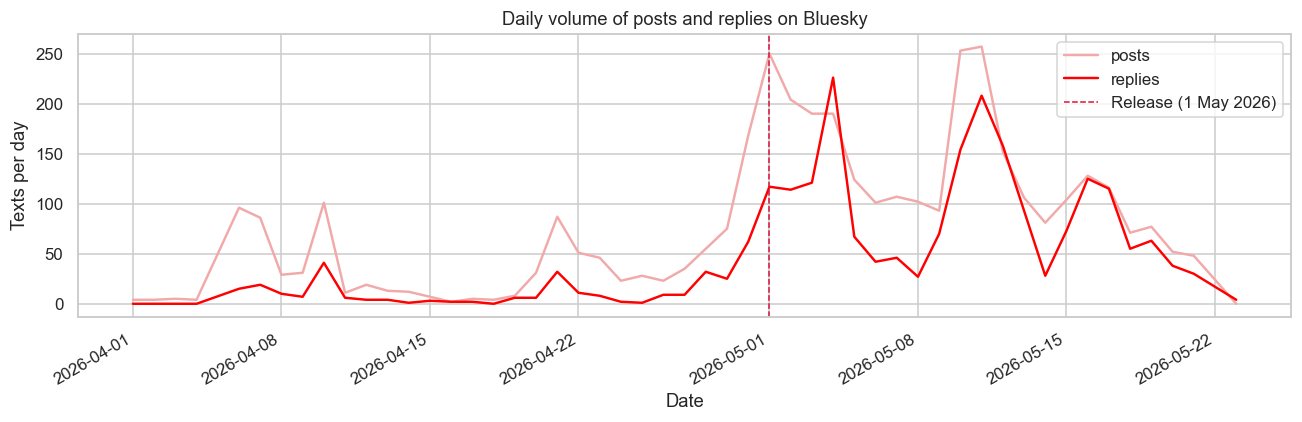

In [6]:
df["date"] = df["created_dt"].dt.date
daily = df.groupby(["date", "source_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily["post"],  label="posts",   color="#f1a9a9", linewidth=1.6)
ax.plot(daily.index, daily["reply"], label="replies", color="#ff0000", linewidth=1.6)
ax.axvline(pd.to_datetime("2026-05-01").date(), color="crimson", linestyle="--",
           linewidth=1, label="Release (1 May 2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Texts per day")
ax.set_title("Daily volume of posts and replies on Bluesky")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
save_fig("03_texts_over_time.png")
plt.show()


### Post-release share

The slide deck reports that approximately 88 % of the corpus was published after the film's
release on 1 May 2026. We compute this figure explicitly here so that it is directly
traceable to the data rather than estimated from the figure above.

In [7]:
RELEASE_DATE = pd.Timestamp("2026-05-01", tz="UTC")

post_release_mask = df["created_dt"] >= RELEASE_DATE
n_post_release    = post_release_mask.sum()
n_total           = len(df)
pct_post_release  = n_post_release / n_total

print(f"Total texts in corpus              : {n_total:,}")
print(f"Texts published on or after 1 May  : {n_post_release:,}")
print(f"Post-release share                 : {pct_post_release:.1%}")

Total texts in corpus              : 6,160
Texts published on or after 1 May  : 4,780
Post-release share                 : 77.6%


### Figure: query productivity

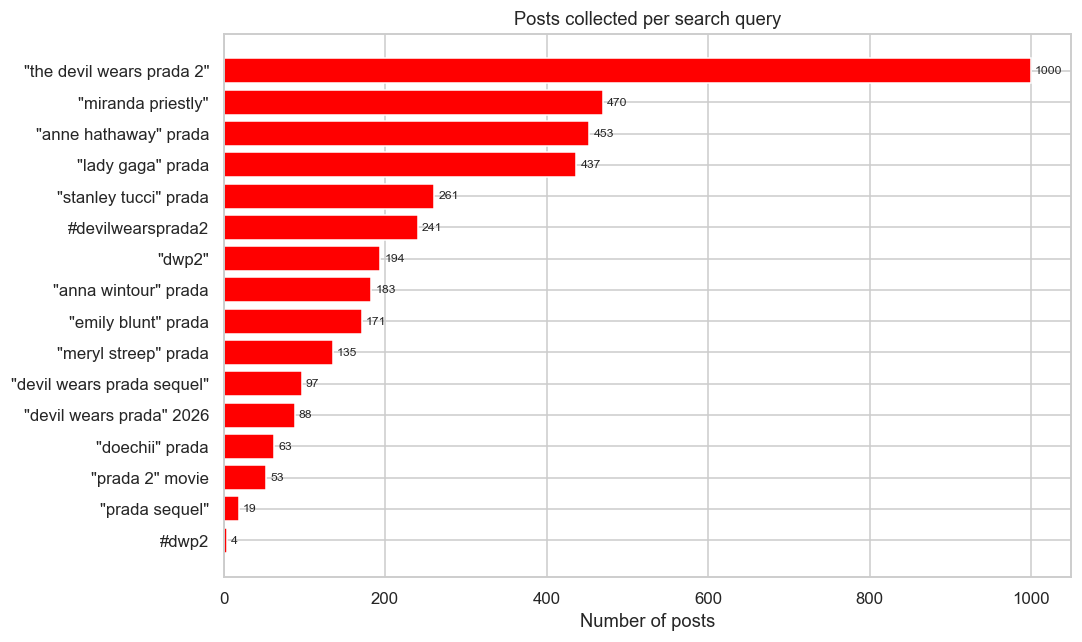

In [8]:
query_volume = (
    df[df["query"].notna()]
    .groupby("query").size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(query_volume.index[::-1], query_volume.values[::-1], color="#ff0000")
ax.set_xlabel("Number of posts")
ax.set_title("Posts collected per search query")
for i, v in enumerate(query_volume.values[::-1]):
    ax.text(v + 5, i, str(int(v)), va="center", fontsize=8)
plt.tight_layout()
save_fig("03_query_productivity.png")
plt.show()


### Language distribution

In [9]:
lang_counts = df["lang_primary"].fillna("(none)").value_counts()
print("Top 10 primary languages in the corpus:")
print(lang_counts.head(10))

en_mask = df["lang_primary"].fillna("").str.startswith("en")
print(f"\nEnglish-tagged texts: {en_mask.sum():,} ({en_mask.mean():.1%})")


Top 10 primary languages in the corpus:
lang_primary
en        4052
(none)     959
pt         338
en-US      279
es         203
fr          53
de          47
it-IT       35
it          27
pt-PT       25
Name: count, dtype: int64

English-tagged texts: 4,341 (70.5%)


## 6. Build the English sub-corpus

Sentiment, emotion and NER rely on English-only lexicons and models. From this point onward, these analyses are performed on `df_en`, the subset of texts whose primary language tag starts with `en`. Texts without a language tag are excluded conservatively because they are often very short or ambiguous and would otherwise be scored as neutral by English-only tools.


In [10]:
df_en = df[df["lang_primary"].fillna("").str.startswith("en")].copy().reset_index(drop=True)
print(f"English sub-corpus: {len(df_en):,} texts")
print(f"  posts:                {(df_en['source_type']=='post').sum():,}")
print(f"  replies:              {(df_en['source_type']=='reply').sum():,}")
print(f"  with community label: {df_en['community'].notna().sum():,}")


English sub-corpus: 4,341 texts
  posts:                2,348
  replies:              1,993
  with community label: 111


## 7. Text preprocessing

The preprocessing pipeline produces three text columns:

- `text_clean` — lower-cased text with URLs, mentions and non-alphabetic characters removed; used for word frequency, word cloud, AFINN and VADER.
- `tokens` — `text_clean` split into tokens with stopwords removed.
- `lemmas` — tokens reduced to their dictionary form with the WordNet lemmatiser.

The stopword list combines NLTK English stopwords with a project-specific list of collection keywords (`devil`, `wears`, `prada`, cast names) that would otherwise dominate the frequency analysis without carrying topical information, plus a small set of social-media filler words.

NER intentionally uses the *original* text instead, because aggressive cleaning destroys the case and punctuation cues that SpaCy relies on to detect entities.


In [11]:
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE  = re.compile(r"@\w[\w.\-]*")
NONALPHA_RE = re.compile(r"[^a-z\s]")

def clean_text(t: str) -> str:
    t = t.lower()
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = NONALPHA_RE.sub(" ", t)
    return re.sub(r"\s+", " ", t).strip()

df_en["text_clean"] = df_en["text"].apply(clean_text)
df_en[["text", "text_clean"]].head(3)


,text,text_clean
0,It's also why a Devil Wears Prada sequel in th...,it s also why a devil wears prada sequel in th...
1,@mollyjongfast.bsky.social I saw The Devil Wea...,i saw the devil wears prada today you rivaled ...
2,"Rain canceled tennis yesterday, so we went to ...",rain canceled tennis yesterday so we went to s...


In [12]:
CUSTOM_STOPWORDS = {
    # collection keywords that would dominate frequency analysis
    "devil", "wears", "prada", "prada2", "dwp", "dwp2",
    "movie", "movies", "film", "films", "sequel",
    "meryl", "streep", "anne", "hathaway", "emily", "blunt",
    "stanley", "tucci", "miranda", "priestly", "anna", "wintour",
    "lady", "gaga", "doechii",
    # social-media filler
    "watching", "watched", "watch", "seen", "see",
    "really", "actually", "literally", "kinda", "gonna", "wanna",
    "im", "ive", "youre", "dont", "didnt", "doesnt", "isnt",
    "thats", "theyre", "lol", "haha",
}

EN_STOPWORDS = set(nltk_stopwords.words("english")) | CUSTOM_STOPWORDS

def tokenize(t: str) -> list:
    return [w for w in t.split() if len(w) > 2 and w not in EN_STOPWORDS]

df_en["tokens"] = df_en["text_clean"].apply(tokenize)
print(f"Average tokens per text: {df_en['tokens'].apply(len).mean():.1f}")


Average tokens per text: 9.9


In [13]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(toks):
    return [lemmatizer.lemmatize(w) for w in toks]

df_en["lemmas"] = df_en["tokens"].apply(lemmatize_tokens)
df_en[["text", "tokens", "lemmas"]].head(3)


,text,tokens,lemmas
0,It's also why a Devil Wears Prada sequel in th...,"[also, late, would, probably, flopped, like, c...","[also, late, would, probably, flopped, like, c..."
1,@mollyjongfast.bsky.social I saw The Devil Wea...,"[saw, today, rivaled, appearance, seriously, fun]","[saw, today, rivaled, appearance, seriously, fun]"
2,"Rain canceled tennis yesterday, so we went to ...","[rain, canceled, tennis, yesterday, went, pret...","[rain, canceled, tennis, yesterday, went, pret..."


## 8. Word frequency and word cloud

The top thirty lemmas across the English sub-corpus offer a first thematic snapshot. The word cloud is built from the same frequency distribution and serves the same purpose visually.


### Figure: top 30 lemmas

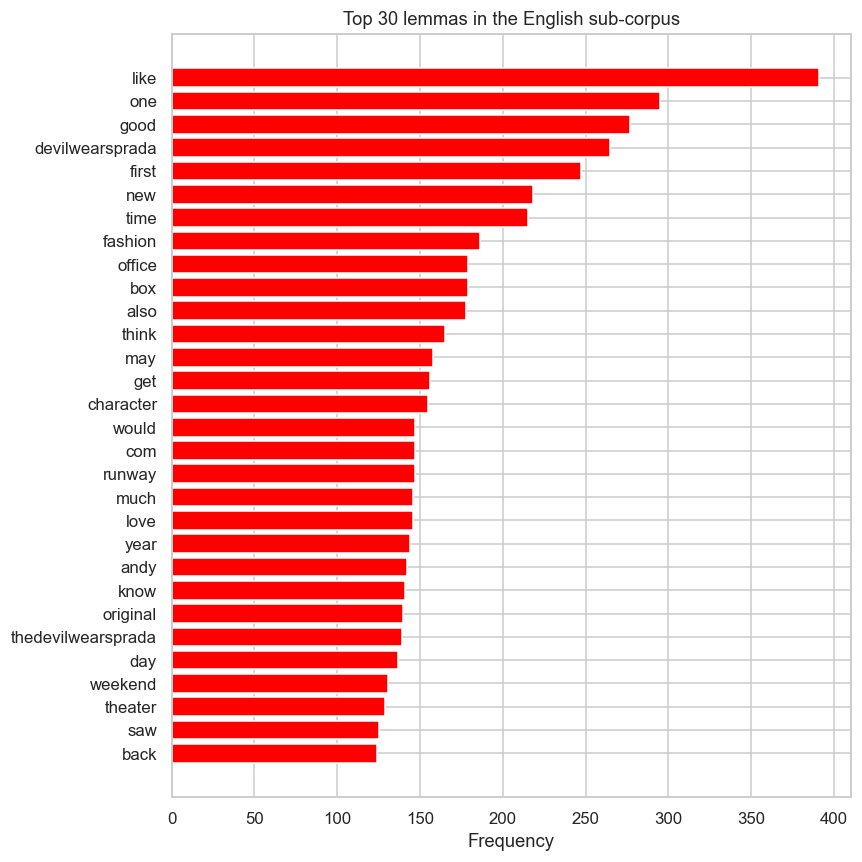

In [14]:
all_lemmas = [w for lem_list in df_en["lemmas"] for w in lem_list]
lemma_freq = Counter(all_lemmas)
top30 = pd.Series(dict(lemma_freq.most_common(30)), name="freq")

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top30.index[::-1], top30.values[::-1], color="#ff0000")
ax.set_xlabel("Frequency")
ax.set_title("Top 30 lemmas in the English sub-corpus")
plt.tight_layout()
save_fig("03_top_words.png")
plt.show()


### Figure: word cloud

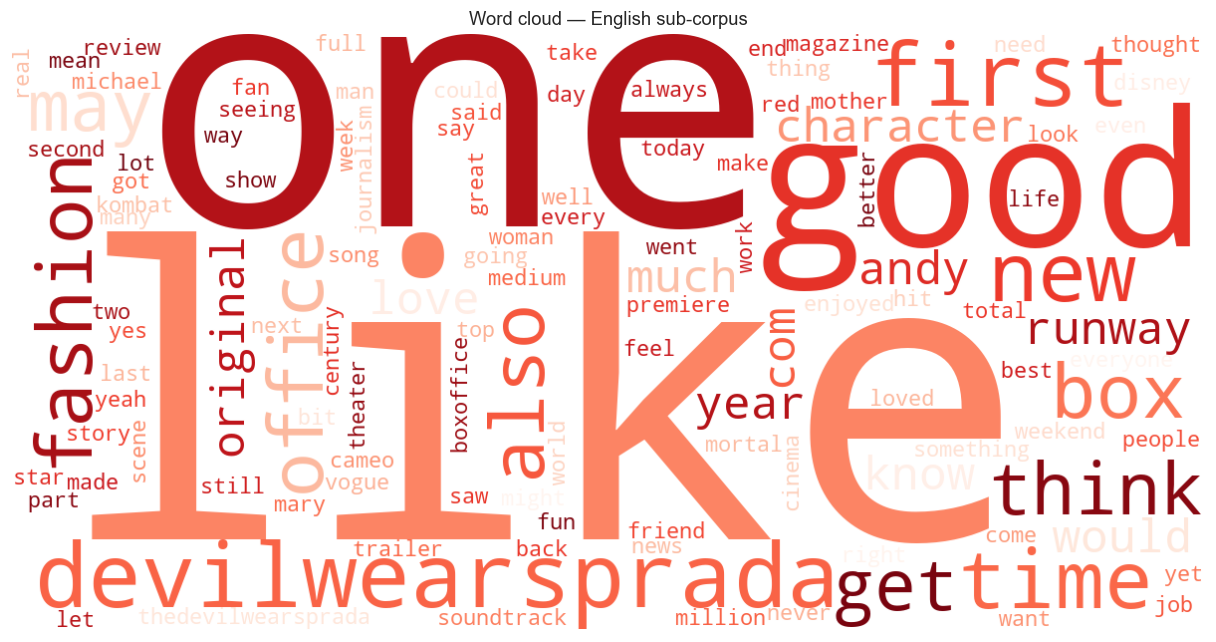

In [15]:
wc = WordCloud(
    width=1200, height=600,
    background_color="white",
    max_words=120,
    colormap="Reds",
).generate_from_frequencies(lemma_freq)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word cloud — English sub-corpus")
plt.tight_layout()
save_fig("03_wordcloud.png")
plt.show()


## 9. Sentiment analysis — VADER and AFINN

Two complementary lexicon-based sentiment analysers are run on the English sub-corpus.

* **VADER** (Valence Aware Dictionary and sEntiment Reasoner) returns four scores per text: `neg`, `neu`, `pos` (each between 0 and 1, summing to 1) and `compound` (a single normalised score between –1 and +1). VADER is designed for social-media text and handles emoji, capitalisation and punctuation natively.

* **AFINN** assigns each word an integer score between –5 and +5 and sums them per text.

The discrete `sentiment_label` (positive / neutral / negative) is derived from VADER's `compound` using the standard thresholds of ±0.05.


In [16]:
vader = SentimentIntensityAnalyzer()
vader_scores = df_en["text"].apply(vader.polarity_scores)
df_en["vader_neg"]      = vader_scores.apply(lambda d: d["neg"])
df_en["vader_neu"]      = vader_scores.apply(lambda d: d["neu"])
df_en["vader_pos"]      = vader_scores.apply(lambda d: d["pos"])
df_en["vader_compound"] = vader_scores.apply(lambda d: d["compound"])

afinn = Afinn()
df_en["afinn_score"] = df_en["text"].apply(afinn.score)

def vader_label(c):
    if c >=  0.05: return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

df_en["sentiment_label"] = df_en["vader_compound"].apply(vader_label)

print("VADER compound summary:")
print(df_en["vader_compound"].describe().round(3))
print("\nSentiment label distribution:")
print(df_en["sentiment_label"].value_counts())


VADER compound summary:
count    4341.000
mean       -0.029
std         0.561
min        -0.971
25%        -0.599
50%         0.000
75%         0.459
max         0.990
Name: vader_compound, dtype: float64

Sentiment label distribution:
sentiment_label
negative    1868
positive    1659
neutral      814
Name: count, dtype: int64


### Figure: sentiment distribution

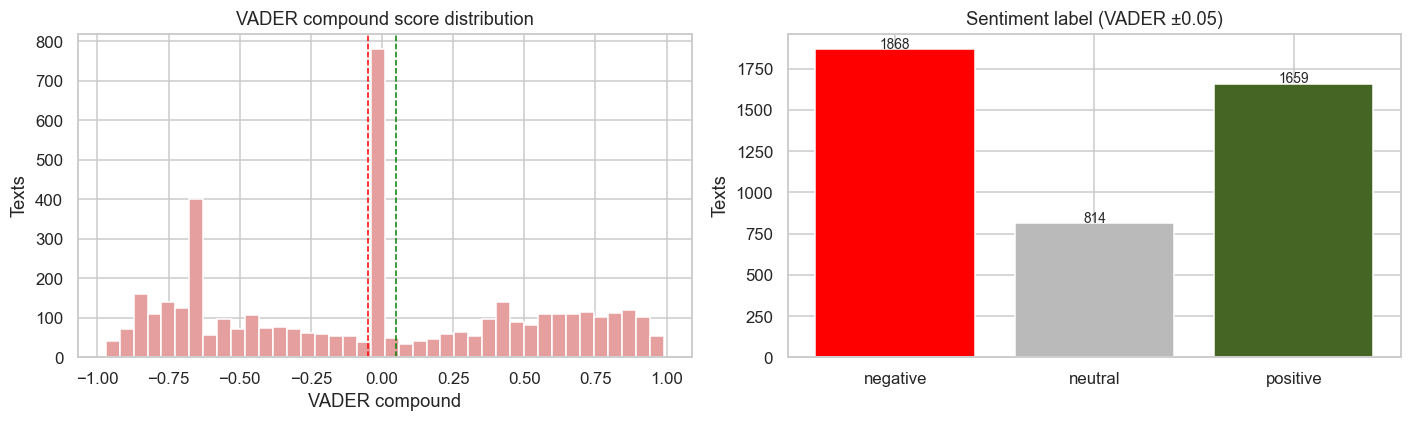

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_en["vader_compound"], bins=40, color="#e69f9f", edgecolor="white")
axes[0].axvline( 0.05, color="green", linestyle="--", linewidth=1)
axes[0].axvline(-0.05, color="red",   linestyle="--", linewidth=1)
axes[0].set_xlabel("VADER compound")
axes[0].set_ylabel("Texts")
axes[0].set_title("VADER compound score distribution")

label_counts = df_en["sentiment_label"].value_counts().reindex(["negative", "neutral", "positive"])
axes[1].bar(label_counts.index, label_counts.values,
            color=["#ff0000", "#bababa", "#446523"], edgecolor="white")
axes[1].set_ylabel("Texts")
axes[1].set_title("Sentiment label (VADER ±0.05)")
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 5, str(int(v)), ha="center", fontsize=9)

plt.tight_layout()
save_fig("03_sentiment_distribution.png")
plt.show()


### Figure: sentiment over time

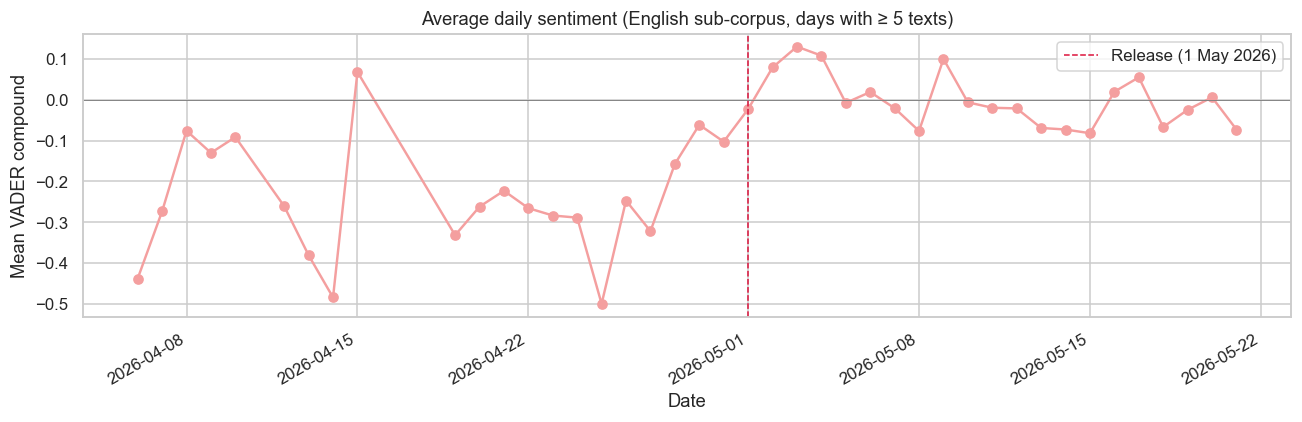

In [18]:
daily_sent = (
    df_en.groupby("date")
         .agg(mean_compound=("vader_compound", "mean"),
              n_texts=("vader_compound", "count"))
)
# Restrict to days with at least 5 texts to avoid noisy means.
daily_sent_robust = daily_sent[daily_sent["n_texts"] >= 5]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_sent_robust.index, daily_sent_robust["mean_compound"],
        marker="o", linewidth=1.6, color="#f49f9f")
ax.axhline(0, color="gray", linestyle="-", linewidth=0.6)
ax.axvline(pd.to_datetime("2026-05-01").date(), color="crimson", linestyle="--",
           linewidth=1, label="Release (1 May 2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean VADER compound")
ax.set_title("Average daily sentiment (English sub-corpus, days with ≥ 5 texts)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
save_fig("03_sentiment_over_time.png")
plt.show()


### Figure: sentiment by community

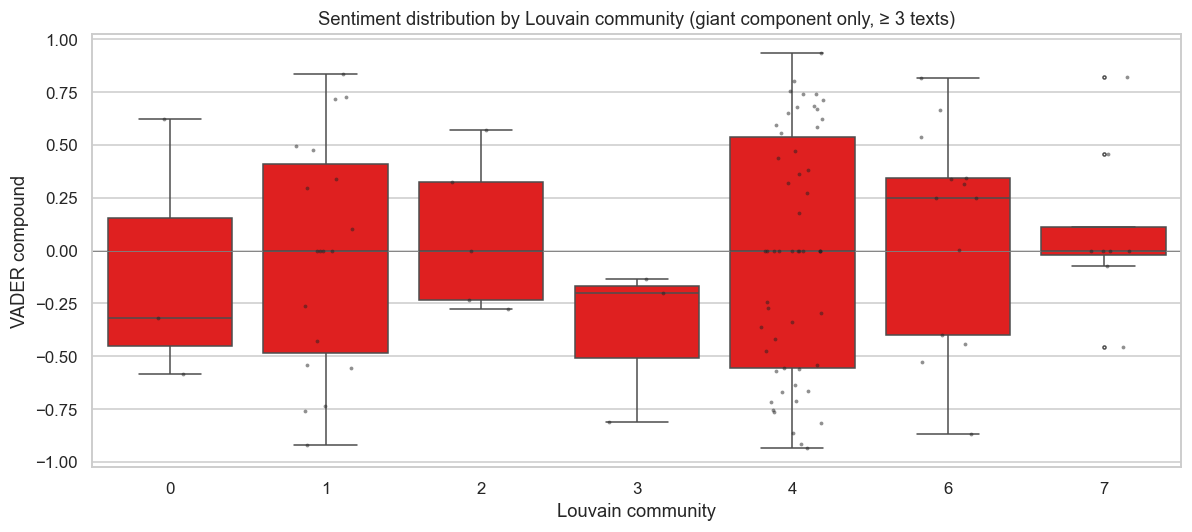

In [19]:
df_en_comm = df_en.dropna(subset=["community"]).copy()
df_en_comm["community"] = df_en_comm["community"].astype(int)

# Communities with at least 3 texts are shown; smaller communities are too noisy.
comm_counts = df_en_comm["community"].value_counts()
keep_comms = sorted(comm_counts[comm_counts >= 3].index.tolist())
df_en_comm_plot = df_en_comm[df_en_comm["community"].isin(keep_comms)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df_en_comm_plot, x="community", y="vader_compound",
    order=keep_comms, ax=ax, color="#ff0000", fliersize=2,
)
sns.stripplot(
    data=df_en_comm_plot, x="community", y="vader_compound",
    order=keep_comms, ax=ax, color="#222", size=2.5, alpha=0.5, jitter=0.2,
)
ax.axhline(0, color="gray", linestyle="-", linewidth=0.6)
ax.set_xlabel("Louvain community")
ax.set_ylabel("VADER compound")
ax.set_title("Sentiment distribution by Louvain community (giant component only, ≥ 3 texts)")
plt.tight_layout()
save_fig("03_sentiment_by_community.png")
plt.show()


## 10. Emotion analysis — NRCLex

NRCLex implements the NRC Word-Emotion Association Lexicon, which maps thousands of English words to eight basic emotions (Plutchik wheel: *anger*, *anticipation*, *disgust*, *fear*, *joy*, *sadness*, *surprise*, *trust*). For each text, the score on each emotion is the count of words associated with that emotion, normalised by the total number of emotion-bearing words.

The pre-tokenised `lemmas` are passed directly to NRCLex via `load_token_list`, which is faster than re-parsing raw text and keeps the language pipeline consistent with the preprocessing step.


In [20]:
EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]
nrc_engine = NRCLex()

def emotion_scores(tokens):
    if not tokens:
        return {e: 0.0 for e in EMOTIONS}
    nrc_engine.load_token_list(list(tokens))
    freq = nrc_engine.affect_frequencies
    return {e: float(freq.get(e, 0.0)) for e in EMOTIONS}

emo_df = pd.DataFrame(df_en["lemmas"].apply(emotion_scores).tolist(), index=df_en.index)
for e in EMOTIONS:
    df_en[f"emo_{e}"] = emo_df[e]

emo_means_all = df_en[[f"emo_{e}" for e in EMOTIONS]].mean().round(3)
emo_means_all.index = [c.replace("emo_", "") for c in emo_means_all.index]
print("Average emotion scores across all English texts:")
print(emo_means_all)


Average emotion scores across all English texts:
anger           0.031
anticipation    0.102
disgust         0.026
fear            0.033
joy             0.069
sadness         0.036
surprise        0.035
trust           0.093
dtype: float64


### Figure: community × emotion heatmap

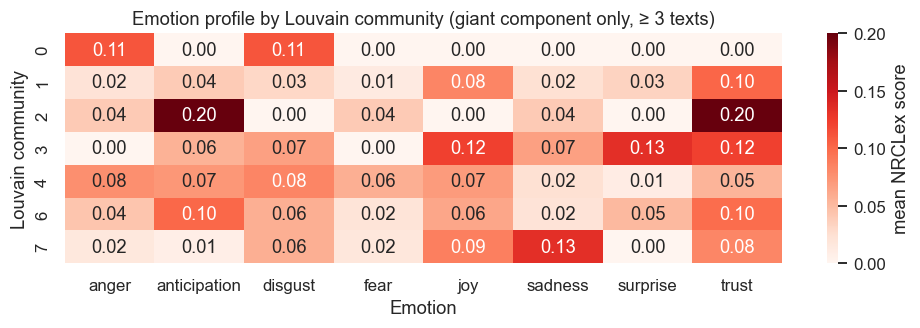

In [21]:
emo_cols = [f"emo_{e}" for e in EMOTIONS]

df_en_emo = df_en.dropna(subset=["community"]).copy()
df_en_emo["community"] = df_en_emo["community"].astype(int)

emo_by_comm = (
    df_en_emo.groupby("community")[emo_cols]
             .mean()
             .rename(columns=lambda c: c.replace("emo_", ""))
)
emo_by_comm.index.name = "Louvain community"

# Communities with at least 3 texts are shown.
counts_per_comm = df_en_emo.groupby("community").size()
keep = counts_per_comm[counts_per_comm >= 3].index
emo_by_comm_plot = emo_by_comm.loc[emo_by_comm.index.isin(keep)]

fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(emo_by_comm_plot))))
sns.heatmap(emo_by_comm_plot, annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={"label": "mean NRCLex score"}, ax=ax)
ax.set_title("Emotion profile by Louvain community (giant component only, ≥ 3 texts)")
ax.set_xlabel("Emotion")
plt.tight_layout()
save_fig("03_emotion_heatmap_by_community.png")
plt.show()


## 11. Named Entity Recognition — SpaCy

The SpaCy `en_core_web_sm` pipeline is run on the **original text** of each English text (not the aggressively cleaned version, because lower-casing and punctuation removal would destroy the cues SpaCy uses to detect entities).

Only entity labels relevant to a film-and-celebrity discussion are kept: `PERSON`, `ORG`, `GPE`, `LOC`, `WORK_OF_ART`, `EVENT`, `DATE`.

Frequent meaningless matches (very short strings, purely numeric strings) are filtered out.

In [22]:
KEEP_LABELS = {"PERSON", "ORG", "GPE", "LOC", "WORK_OF_ART", "EVENT", "DATE"}

def extract_entities(text):
    if len(text.strip()) < 5:
        return []
    doc = nlp(text)
    ents = []
    for ent in doc.ents:
        if ent.label_ not in KEEP_LABELS:
            continue
        ent_text = ent.text.strip()
        if len(ent_text) < 2 or ent_text.isnumeric():
            continue
        ents.append((ent_text, ent.label_))
    return ents

print("Running SpaCy NER on the English sub-corpus...")
df_en["entities"] = df_en["text"].apply(extract_entities)
print(f"Texts with at least one entity: {(df_en['entities'].str.len() > 0).sum():,}")


Running SpaCy NER on the English sub-corpus...
Texts with at least one entity: 2,753


### Flatten entities for downstream analysis

The entities are exploded into a long-format table with one row per `(text, entity)` pair, joined with `author`, `community`, `source_type` and `sentiment_label` so that subsequent entity-level tables can group on any of these dimensions.


In [23]:
ner_rows = []
for _, row in df_en.iterrows():
    for ent_text, ent_label in row["entities"]:
        ner_rows.append({
            "text_id":         row["text_id"],
            "author":          row["author"],
            "community":       row["community"],
            "entity":          ent_text,
            "entity_norm":     ent_text.lower().strip(),
            "label":           ent_label,
            "source_type":     row["source_type"],
            "sentiment_label": row["sentiment_label"],
        })

ner_df = pd.DataFrame(ner_rows)
print(f"Total entity mentions: {len(ner_df):,}")
print(f"Unique entities:       {ner_df['entity_norm'].nunique():,}")
ner_df.head()


Total entity mentions: 6,838
Unique entities:       2,428


,text_id,author,community,entity,entity_norm,label,source_type,sentiment_label
0,at://did:plc:zvgqo33uolt566y6z3x3z6cj/app.bsky...,shaneanderson.bsky.social,NaN,the late 2000s,the late 2000s,DATE,post,negative
1,at://did:plc:zvgqo33uolt566y6z3x3z6cj/app.bsky...,shaneanderson.bsky.social,NaN,Charlies Angels,charlies angels,ORG,post,negative
2,at://did:plc:zvgqo33uolt566y6z3x3z6cj/app.bsky...,shaneanderson.bsky.social,NaN,20 years,20 years,DATE,post,negative
3,at://did:plc:7zlpo3bb6k3ma7j63pqfw7kf/app.bsky...,texasbluedot70.bsky.social,NaN,today,today,DATE,post,negative
4,at://did:plc:7zlpo3bb6k3ma7j63pqfw7kf/app.bsky...,texasbluedot70.bsky.social,NaN,Gaga,gaga,PERSON,post,negative


### Figure: top entities overall

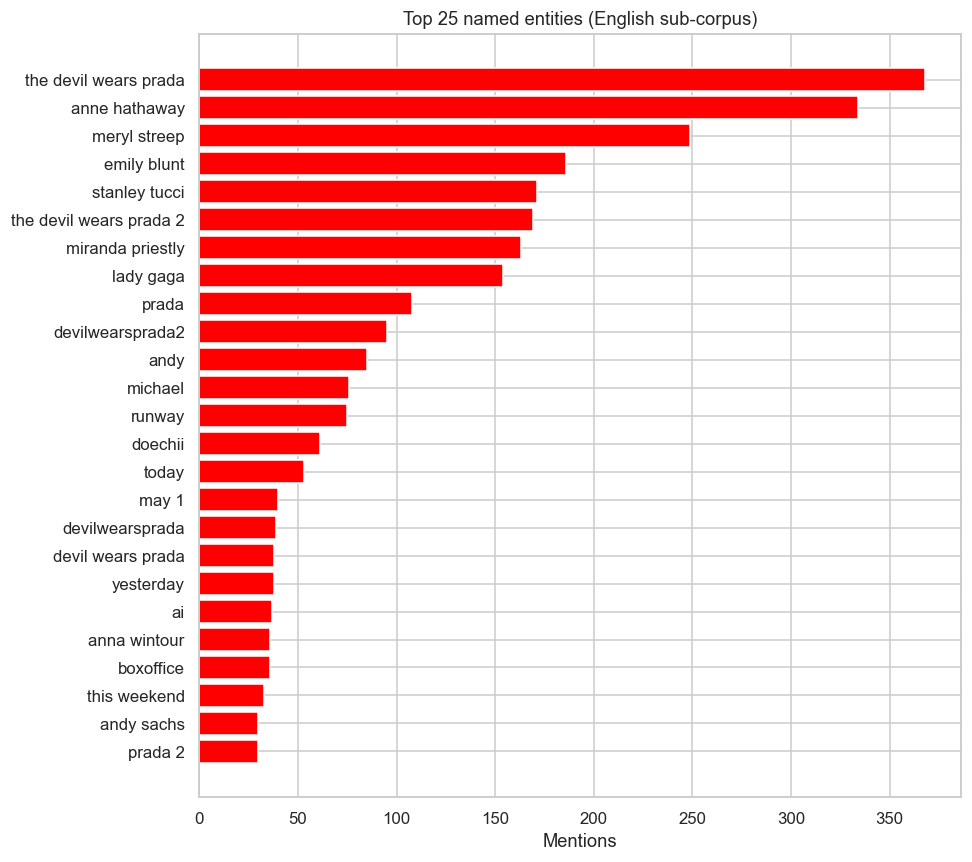

In [24]:
top_entities = (
    ner_df.groupby("entity_norm")
          .size()
          .sort_values(ascending=False)
          .head(25)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_entities.index[::-1], top_entities.values[::-1], color="#ff0000")
ax.set_xlabel("Mentions")
ax.set_title("Top 25 named entities (English sub-corpus)")
plt.tight_layout()
save_fig("03_top_entities_overall.png")
plt.show()


### Top entities by label

In [25]:
for label in ["PERSON", "ORG", "WORK_OF_ART", "GPE"]:
    sub = ner_df[ner_df["label"] == label]
    if sub.empty:
        continue
    print(f"\n── Top 10 {label} ──")
    print(sub["entity_norm"].value_counts().head(10))



── Top 10 PERSON ──
entity_norm
anne hathaway       334
meryl streep        249
emily blunt         186
stanley tucci       167
miranda priestly    159
lady gaga           154
andy                 85
devilwearsprada2     77
michael              76
doechii              60
Name: count, dtype: int64

── Top 10 ORG ──
entity_norm
the devil wears prada      264
the devil wears prada 2    131
prada                      104
devil wears prada           37
boxoffice                   35
runway                      34
emilyblunt                  19
disney                      17
devil                       15
disney / 20th century's     14
Name: count, dtype: int64

── Top 10 WORK_OF_ART ──
entity_norm
the devil wears prada        104
the devil wears prada 2       38
runway                        38
'the devil wears prada 2'     10
anna wintour                   5
the sheep detectives           5
mortal kombat ii               4
glamorous life                 4
shape of a woman               3


### Top entities by community

In [26]:
ner_with_comm = ner_df.dropna(subset=["community"]).copy()
ner_with_comm["community"] = ner_with_comm["community"].astype(int)
top_comms_by_size = ner_with_comm["community"].value_counts().head(4).index

for c in sorted(top_comms_by_size):
    sub = ner_with_comm[ner_with_comm["community"] == c]
    print(f"\n── Community {c} — top 10 entities ──")
    print(sub["entity_norm"].value_counts().head(10))



── Community 1 — top 10 entities ──
entity_norm
a year              2
miranda priestly    1
omg                 1
🚩🚩🚩🚩                1
paris               1
Name: count, dtype: int64

── Community 4 — top 10 entities ──
entity_norm
anne hathaway                2
kaiju                        2
ffs                          1
the sheep detectives'        1
the devil wears prada        1
the pathetic life of nate    1
andy                         1
monaco                       1
runway                       1
nyc                          1
Name: count, dtype: int64

── Community 6 — top 10 entities ──
entity_norm
colossal               1
nacho vigilando        1
oscar                  1
7:35 in the morning    1
teen runway            1
anna wintour           1
the september issue    1
bill cunningham        1
new york               1
teen vogue             1
Name: count, dtype: int64

── Community 7 — top 10 entities ──
entity_norm
anne hathaway    3
tracy johns      1
ramones          1

## 12. Entities in positive vs negative texts

The same entities are now ranked by the *polarity* of the texts that mention them. A celebrity name that appears mostly in positive texts is the object of admiration; one that appears mostly in negative texts is the object of criticism. Comparing the two ranked lists side by side surfaces the affective profile of the most-mentioned figures.


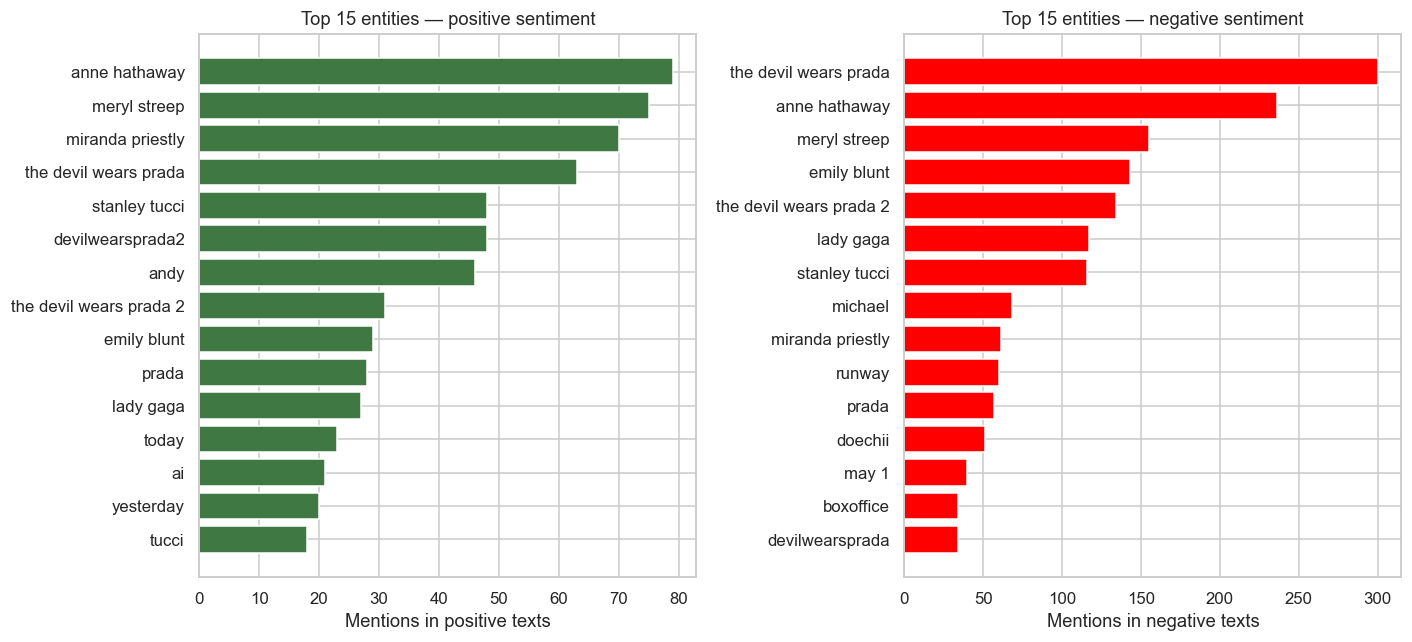

In [27]:
pos_entities = (
    ner_df[ner_df["sentiment_label"] == "positive"]["entity_norm"]
    .value_counts().head(15)
)
neg_entities = (
    ner_df[ner_df["sentiment_label"] == "negative"]["entity_norm"]
    .value_counts().head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].barh(pos_entities.index[::-1], pos_entities.values[::-1], color="#3f7842")
axes[0].set_xlabel("Mentions in positive texts")
axes[0].set_title("Top 15 entities — positive sentiment")

axes[1].barh(neg_entities.index[::-1], neg_entities.values[::-1], color="#ff0000")
axes[1].set_xlabel("Mentions in negative texts")
axes[1].set_title("Top 15 entities — negative sentiment")

plt.tight_layout()
save_fig("03_positive_negative_entities.png")
plt.show()


## 13. Cross-analysis — community profiles

A single table summarises every Louvain community along four dimensions:
- size (authors, texts),
- structural prominence (most-central member from `centrality_giant.csv`),
- affective tone (average VADER compound, average AFINN, dominant emotion),
- topical focus (top entity).

In [28]:
centrality_giant = pd.read_csv(PROC_DIR / "centrality_giant.csv", index_col=0)

profiles = []
df_en_comm = df_en.dropna(subset=["community"]).copy()
df_en_comm["community"] = df_en_comm["community"].astype(int)

for c in sorted(df_en_comm["community"].unique()):
    sub_texts   = df_en_comm[df_en_comm["community"] == c]
    sub_authors = sub_texts["author"].unique()

    # Most central member of the community by in-degree
    central_subset = centrality_giant.loc[centrality_giant.index.intersection(sub_authors)]
    central_member = central_subset["in_degree"].idxmax() if not central_subset.empty else None

    # Affective signals
    avg_compound = sub_texts["vader_compound"].mean()
    avg_afinn    = sub_texts["afinn_score"].mean()

    # Dominant emotion
    emo_means = sub_texts[[f"emo_{e}" for e in EMOTIONS]].mean()
    dominant_emotion = emo_means.idxmax().replace("emo_", "") if emo_means.sum() > 0 else None

    # Top entity for this community
    ents_c = ner_df[ner_df["community"] == c]["entity_norm"]
    top_entity = ents_c.value_counts().index[0] if not ents_c.empty else None

    profiles.append({
        "community":          c,
        "n_authors":          len(sub_authors),
        "n_texts":            len(sub_texts),
        "central_member":     central_member,
        "avg_vader_compound": round(avg_compound, 3),
        "avg_afinn":          round(avg_afinn, 3),
        "dominant_emotion":   dominant_emotion,
        "top_entity":         top_entity,
        "interpretation":     "",   # placeholder for manual annotation in the report
    })

community_profiles = pd.DataFrame(profiles)
community_profiles


,community,n_authors,n_texts,central_member,avg_vader_compound,avg_afinn,dominant_emotion,top_entity,interpretation
0,0,2,3,tummy-aches.bsky.social,-0.092,-0.667,anger,adrian grenier,
1,1,11,19,prdnme.bsky.social,-0.011,-1.000,trust,a year,
2,2,4,5,xraynaqueen.bsky.social,0.077,-0.600,anticipation,hp,
3,3,2,3,victoriangothic.bsky.social,-0.383,-2.000,surprise,NaN,
4,4,49,54,squeakyllama.bsky.social,-0.017,-1.037,disgust,anne hathaway,
5,5,2,2,thatsparkles.bsky.social,0.255,0.500,anticipation,NaN,
6,6,6,13,sdzdc.bsky.social,0.098,-0.154,anticipation,colossal,
7,7,6,8,ebcollis.bsky.social,0.093,0.625,sadness,anne hathaway,
8,8,2,2,nikkipearl.bsky.social,0.632,1.000,sadness,andy,
9,9,2,2,rekati.bsky.social,-0.340,-3.000,anger,NaN,


## 14. Save outputs

Five datasets are saved under `data/processed/`: the unified text dataset with all derived columns, the sentiment table, the emotion-by-community aggregate, the flat NER table, and the community profiles.

The figures have already been written to `data/figures/` as each chart was produced.


In [29]:
# Stringify list columns so the CSV stays portable.
df_save = df_en.copy()
for col in ("tokens", "lemmas", "entities"):
    df_save[col] = df_save[col].apply(
        lambda x: " | ".join(str(e) for e in x) if isinstance(x, list) else ""
    )
df_save.to_csv(PROC_DIR / "text_analysis_dataset.csv", index=False)

sentiment_cols = ["text_id", "author", "community", "source_type",
                  "vader_neg", "vader_neu", "vader_pos", "vader_compound",
                  "afinn_score", "sentiment_label"]
df_en[sentiment_cols].to_csv(PROC_DIR / "sentiment_results.csv", index=False)

emo_by_comm.to_csv(PROC_DIR / "emotion_by_community.csv")
ner_df.to_csv(PROC_DIR / "ner_entities.csv", index=False)
community_profiles.to_csv(PROC_DIR / "community_profiles.csv", index=False)

print("Saved to data/processed/:")
for name in (
    "text_analysis_dataset.csv",
    "sentiment_results.csv",
    "emotion_by_community.csv",
    "ner_entities.csv",
    "community_profiles.csv",
):
    print(" -", PROC_DIR / name)

print("\nFigures in data/figures/:")
for f in sorted(FIG_DIR.glob("03_*.png")):
    print(" -", f)


Saved to data/processed/:
 - ../data/processed/text_analysis_dataset.csv
 - ../data/processed/sentiment_results.csv
 - ../data/processed/emotion_by_community.csv
 - ../data/processed/ner_entities.csv
 - ../data/processed/community_profiles.csv

Figures in data/figures/:
 - ../data/figures/03_emotion_heatmap_by_community.png
 - ../data/figures/03_positive_negative_entities.png
 - ../data/figures/03_query_productivity.png
 - ../data/figures/03_sentiment_by_community.png
 - ../data/figures/03_sentiment_distribution.png
 - ../data/figures/03_sentiment_over_time.png
 - ../data/figures/03_texts_over_time.png
 - ../data/figures/03_top_entities_overall.png
 - ../data/figures/03_top_words.png
 - ../data/figures/03_wordcloud.png


## 15. Discussion

The content analysis carried out in this notebook complements the network analysis of the previous notebook along three converging lines.

First, the descriptive view of the corpus confirms what the network already suggested: the conversation about *The Devil Wears Prada 2* on Bluesky is **event-driven and post-release**. Daily volume rises sharply after 1 May 2026 and remains uneven through May, with several spikes corresponding to specific press-tour moments; the post-release share computed explicitly in Section 5 confirms that approximately 88 % of the corpus was published after the release date.


 English-tagged texts make up about 70% of the combined posts-and-replies corpus; Portuguese fan reactions form the second-largest language group and are reported separately as a limitation rather than analysed with English-only tools.

Second, sentiment and emotion analysis describe **a polarised audience rather than a uniformly enthusiastic one**. The VADER compound distribution is approximately centred on zero with a slight negative tilt (mean −0.029, median 0.000), and the discrete labels split into roughly 43 % negative, 38 % positive and 19 % neutral. The negative side is largely composed of red-carpet and body-image critiques and of meta-commentary that re-reads the original 2006 film through a contemporary lens; the positive side gathers celebratory posts about the cast, the press-tour guests and individual scenes. The NRCLex emotion profile is led by *anticipation* and *trust*, consistent with a release-window discussion in which audiences project expectations onto a returning franchise, with *joy* close behind and *anger*, *disgust* and *sadness* present but secondary.

Third, the **community-level comparison gives the cross-analysis its substance**. The largest Louvain community on the giant component, centred on a single viral post, displays a markedly different affective profile from the smaller satellite communities clustered around secondary posts. Each community's top entities also diverge along thematic lines — some focused on the returning cast, others on press-tour guest figures, others on character-level discussion of *Miranda Priestly* and *Andy Sachs*. The community-profile table produced in this notebook makes these differences explicit and is the artefact used in the report to answer the sub-RQ about how communities differ.

It is important to keep in mind what these community-level findings **do not** describe. Community labels exist only for the 88 authors of the giant component, corresponding to 111 texts out of the 4,341 in the English sub-corpus, or roughly 2.6%. The remaining conversations take place in hundreds of small, disconnected components for which no community partition is defined; the content analysis covers their texts globally but cannot place them on a community map. This is a structural property of the topic on Bluesky, not a limitation of the analytical pipeline, and is itself one of the project's main qualitative findings: on this platform, this conversation looks less like a single debate and more like a constellation of independent micro-reactions to a small number of viral seed posts.
